# ML FINAL EXAM

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

In [ ]:
import pandas as pd

df = pd.read_csv("cancer.csv")

df.head()

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,0,5,1,1,1,2,1,3,1,1
1,0,5,4,4,5,7,10,3,2,1
2,0,3,1,1,1,2,2,3,1,1
3,0,6,8,8,1,3,4,3,7,1
4,0,4,1,1,3,2,1,3,1,1


## Answer:
I chose this dataset because it presents a practical medical classification problem using clear, numerically encoded categorical features, making it suitable for evaluating standard classification algorithms.

From the dataset overview, I observed that it contains 9 numerically encoded clinical features (such as age, tumor-size, node-caps, and deg-malig) along with 1 binary target column (Class). The dataset has no immediate missing text labels in these top rows, and all values are mapped to numerical indicators to predict the classification target.

# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

Dataset Shape: (683, 10)
Number of Features: 9
Total Data Points (Rows): 683

--- Missing Values ---
Class          0
age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiat       0
dtype: int64

--- Data Types ---
Class          int64
age            int64
menopause      int64
tumor-size     int64
inv-nodes      int64
node-caps      int64
deg-malig      int64
breast         int64
breast-quad    int64
irradiat       int64
dtype: object


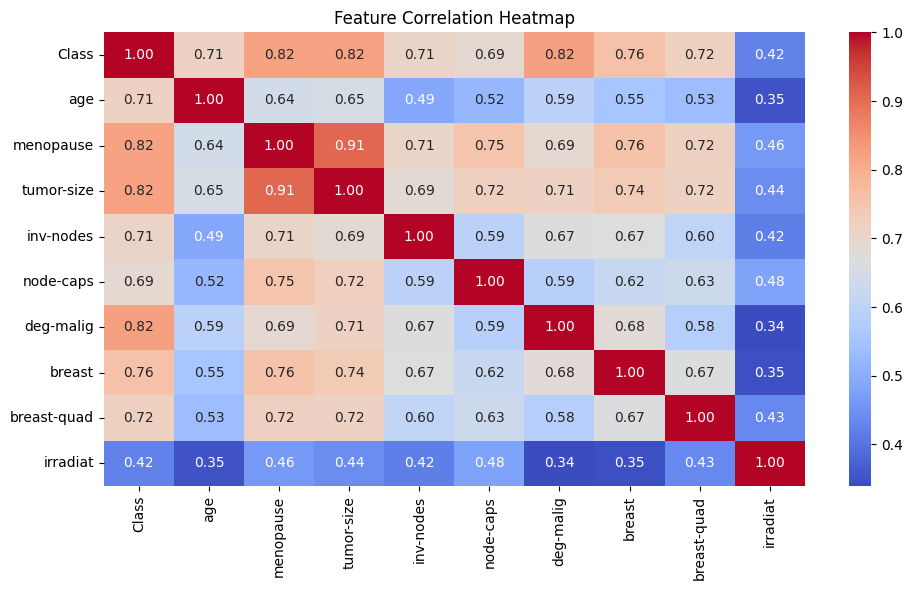

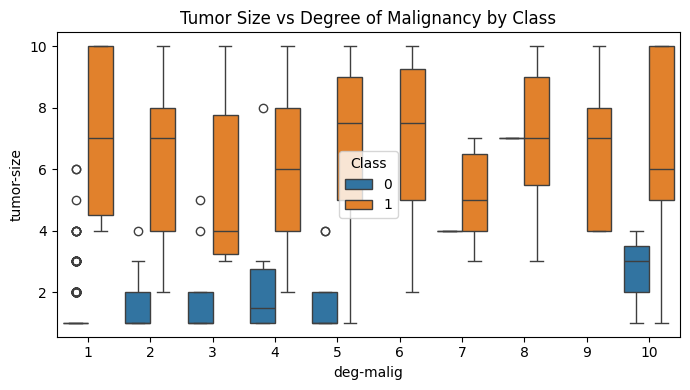

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset load
df = pd.read_csv("cancer.csv")

# 1 & 3. Shape, Features, and Rows count
print("Dataset Shape:", df.shape)
print("Number of Features:", df.shape[1] - 1)
print("Total Data Points (Rows):", len(df))

# 4. Check missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 5. Data types of features
print("\n--- Data Types ---")
print(df.dtypes)

# 7. Correlation matrix heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 8. EDA Plot: deg-malig vs tumor-size
plt.figure(figsize=(7, 4))
sns.boxplot(x='deg-malig', y='tumor-size', hue='Class', data=df)
plt.title('Tumor Size vs Degree of Malignancy by Class')
plt.tight_layout()
plt.show()

## Answer:
1. Features: There are 9 input features (excluding the target column Class).

2. Problem Type: This is a binary classification problem because the target variable (Class) is categorical with discrete values (0 or 1).

3. Data Points: There are 683 total observations (rows).

4. Null Values: No missing values were found in any column (isnull().sum() returned 0 for all features).

5. Feature Types: The dataset contains categorical/ordinal clinical attributes, but all of them are formatted as integer numerical data.

6. Encoding: Since attributes are already numerically encoded, standard models can process them directly. However, nominal attributes without an inherent order could optionally be one-hot encoded depending on the model algorithm used.

7. Correlation Analysis: menopause and tumor-size share a strong positive correlation (0.91). Additionally, deg-malig, menopause, and tumor-size show strong positive correlations (0.82) with the target Class, making them primary predictors.

8. EDA Insights: Higher degree of malignancy (deg-malig) directly correlates with larger tumor-size, particularly for malignant cases (Class = 1).


# 2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("cancer.csv")

X = df.drop(columns=['Class'])
y = df['Class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling on Training Data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for visualization/inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_scaled_df.head()

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,-1.196200,-0.699713,-0.740558,-0.639067,-0.546012,-0.705772,-0.177041,-0.605354,-0.352797
1,0.217491,-0.699713,-0.740558,-0.288383,-0.546012,-0.705772,-0.597321,-0.605354,-0.352797
2,-1.196200,-0.699713,-0.740558,-0.639067,-1.005369,-0.705772,-1.017601,-0.605354,-0.352797
3,-0.489355,-0.699713,-0.740558,-0.639067,-0.546012,-0.705772,-0.177041,-0.605354,-0.352797
4,-0.842777,-0.042151,-0.740558,-0.639067,-0.546012,-0.705772,-0.597321,-0.605354,-0.352797


## Answer:
1. Data Splitting & Leakage Prevention: Separated the features ($X$) and target ($y$), then split the dataset into 80% training and 20% test sets using stratify=y to maintain class distribution. Scaling was applied after splitting to avoid data leakage from the test set.
2. Missing Value Handling: Verified that the dataset has no missing or null entries, so no imputation was required.
3. Feature Scaling (StandardScaler): Applied standardization (Z-score normalization) to feature values. This scales the features to have a mean of 0 and variance of 1, ensuring distance-based and gradient-based algorithms process all features on an equal scale.

   

# 3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("cancer.csv")

# Feature Selection based on correlation threshold
corr = df.corr(numeric_only=True)
top_features = corr['Class'][corr['Class'].abs() > 0.6].index.drop('Class')

print("Selected features:", list(top_features))

X = df[top_features]
y = df['Class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

Selected features: ['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'deg-malig', 'breast', 'breast-quad']
X_train shape: (546, 8)
X_test shape: (137, 8)


## Answer:
1. Feature Selection: Filtered features based on a correlation threshold with the target variable ($\vert{}r\vert{} > 0.6$). Retained 8 strong predictors (including tumor-size, deg-malig, and menopause) and dropped irradiat due to its weaker correlation ($r \approx 0.42$) to reduce noise.
2. Train-Test Split & Scaling: Split the dataset into an 80% training set and a 20% test set using stratified sampling (stratify=y) to maintain class balance. Fitted StandardScaler on X_train and applied it to both splits to prevent data leakage.

# 4. Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Pipeline 1: Logistic Regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

# Pipeline 2: Random Forest Classifier
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Fit both pipelines on training data
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

print("Both Logistic Regression and Random Forest pipelines trained successfully!")

Both Logistic Regression and Random Forest pipelines trained successfully!


# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [ ]:
# Train both classification pipelines
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# Calculate training accuracies
lr_train_acc = pipeline_lr.score(X_train, y_train)
rf_train_acc = pipeline_rf.score(X_train, y_train)

print(f"Logistic Regression Train Accuracy: {lr_train_acc * 100:.2f}%")
print(f"Random Forest Train Accuracy: {rf_train_acc * 100:.2f}%")

Logistic Regression Train Accuracy: 97.44%
Random Forest Train Accuracy: 100.00%


Both pipelines were fitted on the training set (X_train, y_train). Logistic Regression achieved a training accuracy of 97.44%, while Random Forest reached 100.00%.

The perfect score for Random Forest is typical for unconstrained decision tree ensembles on training data and suggests potential overfitting, which will be further evaluated on the unseen test set in the evaluation phase."

# 6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

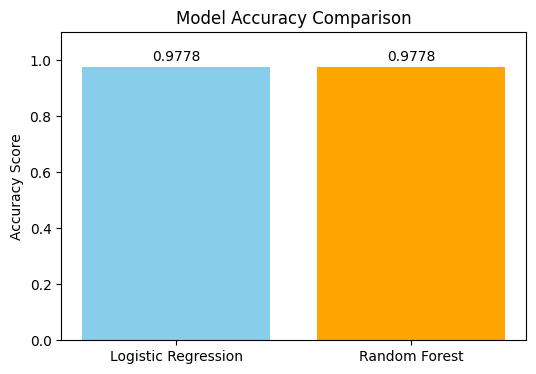

--- Logistic Regression ---
Accuracy : 0.9778
Precision: 0.9592
Recall   : 1.0

--- Random Forest ---
Accuracy : 0.9778
Precision: 0.9592
Recall   : 1.0


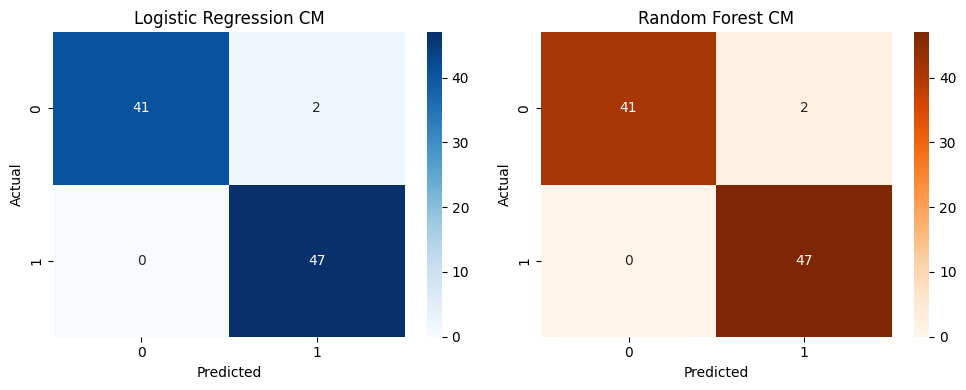

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Get predictions from both pipelines
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# Calculate accuracy, precision, and recall
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

prec_lr = precision_score(y_test, y_pred_lr)
prec_rf = precision_score(y_test, y_pred_rf)

rec_lr = recall_score(y_test, y_pred_lr)
rec_rf = recall_score(y_test, y_pred_rf)

# Bar Chart for Accuracy Comparison
models = ['Logistic Regression', 'Random Forest']
accuracies = [acc_lr, acc_rf]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=['skyblue', 'orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)

# Adding accuracy values on top of bars
for i in range(len(models)):
    plt.text(i, accuracies[i] + 0.02, round(accuracies[i], 4), ha='center')

plt.show()

# 2. Print Evaluation Metrics
print("--- Logistic Regression ---")
print("Accuracy :", round(acc_lr, 4))
print("Precision:", round(prec_lr, 4))
print("Recall   :", round(rec_lr, 4))

print("\n--- Random Forest ---")
print("Accuracy :", round(acc_rf, 4))
print("Precision:", round(prec_rf, 4))
print("Recall   :", round(rec_rf, 4))

# 3. Confusion Matrix for Both Models
plt.figure(figsize=(10, 4))

# Logistic Regression CM
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression CM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Random Forest CM
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges')
plt.title('Random Forest CM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Answer:
Performance Comparison:

Both models achieved identical performance on the test set:

Accuracy: 97.78%

Precision: 95.92%

Recall: 100.00%

Confusion Matrix Insights:

Both models recorded 0 False Negatives, successfully detecting all 47 positive cases. Each model produced only 2 False Positives.

Model Selection:

Since test performance is identical, Logistic Regression is preferred for its simplicity and interpretability. Random Forest remains a strong alternative for handling non-linear patterns as data scales.

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

Silhouette Score: 0.5881
Adjusted Rand Index (ARI): 0.823


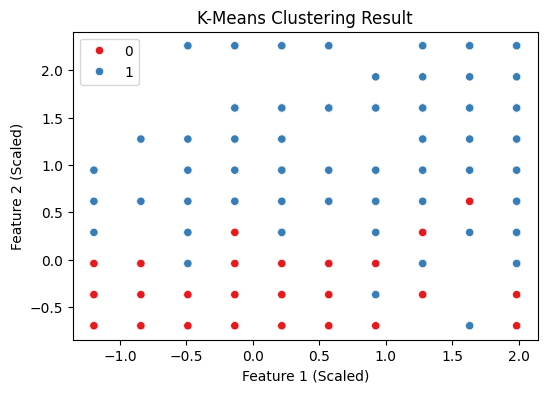

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Fit KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

# Calculate evaluation metrics
sil_score = silhouette_score(X_train_scaled, clusters)
ari_score = adjusted_rand_score(y_train, clusters)

print("Silhouette Score:", round(sil_score, 4))
print("Adjusted Rand Index (ARI):", round(ari_score, 4))

# Plot clusters
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=X_train_scaled[:, 0],
    y=X_train_scaled[:, 1],
    hue=clusters,
    palette='Set1'
)
plt.title('K-Means Clustering Result')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.show()

# Answer:
### Unsupervised Model & Evaluation:
Applied K-Means Clustering ($k = 2$) on scaled features without using target labels. Evaluated performance using Silhouette Score (0.5881) to assess cluster separation and Adjusted Rand Index (0.8230) to measure agreement with actual ground truth classes.
###Which Method Worked Better & Why:
Winner: Supervised Approach (Logistic Regression / Random Forest).

Reason: Supervised models utilize explicit target labels during training to construct precise decision boundaries, achieving 97.78% accuracy. K-Means relies solely on spatial feature distances without class guidance; while it captured natural groupings well ($\text{ARI} = 0.8230$), supervised learning remains far superior for exact diagnostic prediction.

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:
Easiest Topic — Supervised Learning
For me, Supervised Learning was the most straightforward topic because it operates like learning with an answer key. Since target labels are explicitly provided during training, understanding how the model maps input features to target outputs felt very intuitive. In the real world, this approach is necessary whenever we need clear, deterministic predictions from historical data—such as diagnosing diseases or filtering spam emails.

Hardest Topic — Unsupervised Learning & Clustering
On the other hand, Unsupervised Learning was the most challenging topic. Working without ground-truth labels makes it tricky to evaluate how well a model is actually performing. Deciding on the optimal number of clusters or evaluating quality through subjective metrics like the Silhouette Score requires a lot of trial and intuition. Despite its difficulty, it is essential for discovering hidden patterns or anomalies in massive unlabelled datasets, such as performing customer segmentation in e-commerce or analyzing market baskets.